# WP5 — `wp5_05` · The decision half of plan §3.3, as far as it can honestly be taken

**Plan §3.3 is titled *the primary result*: does exposure construction move the *decision*, not just
the exposure?** `wp5_03` measured the exposure displacement (§3.2). This notebook asks what that
displacement does to alerts.

### Why this is not simply blocked

The README recorded §3.3 as blocked behind the §5.1 artifacts, and for its headline bullets that is
right: **re-running the ladder under Builds B and C needs the design matrices, which the repo does
not hold.** `ALT_STATS/frozen/srilanka_matched_pairs.csv` carries *predictions only*.

But the same test that recovered §3.2 and §3.5 applies here — *does the blocker cover all of it?* It
does not. Three things are computable from the frozen artifact alone:

1. **The decision margin, and the flip curve it implies.** How many test rows sit within δ of the
   threshold is a property of the frozen predictions. It is **exact and model-free**: a row can only
   flip if its margin is smaller than the movement applied to it. This is the transfer function from
   *prediction movement* to *decision movement*, and it needs no model at all.
2. **A ceiling.** The file carries `full_*` and `noclim_*` on identical rows, so the decision impact
   of deleting **the entire climate block** is directly observable. Exposure construction perturbs
   climate; it does not delete it.
3. **An estimate of the transfer coefficient.** `logit(full) − logit(noclim)` isolates the
   climate-attributable part of the prediction. Regressing it on the exposure recovers the model's
   *effective* sensitivity to exposure without ever seeing the design matrix.

Together those bracket the answer. **What this cannot do is replace the registered re-run** — the
estimate in (3) is an association fitted to contemporaneous exposure, not the model's partial
derivative, and §12 measures how much that matters rather than waving at it.

### What comes out

A bracket, not a point: exposure construction moves **~1–3%** of alert decisions, against
**10–14%** for deleting climate outright — so the construction choice carries roughly a **fifth to a
quarter** of the climate block's decision leverage. Every number is bounded above by an exact,
model-free quantity.

The sharper finding is in §8.1: those flips run **both ways** and land on district-weeks whose event
rate is close to the panel average, so **`ΔNB` is an order of magnitude smaller than the flip count
suggests**. Exposure construction changes *which* district-weeks are alerted without much changing
*how good* the alerting is.

---
## 1 · Setup, and assert the chain

Same frame, same seed, same geometry hash as every notebook in this series. If the geometry has
moved, nothing downstream is comparable and the notebook stops here.

In [1]:
import json, hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == "notebooks_wp45" else Path.cwd()
M6   = REPO / "data_quarantine" / "m6_geomatics"
QUAR = REPO / "data_quarantine" / "wp5_exposure"
FROZ = REPO / "ALT_STATS" / "frozen"
FIGS = REPO / "Manuscript_Figures" / "wp5"
GEOM = REPO.parent / "dengue_map_workpack" / "geometry" / "rdhs_26_v1.gpkg"
FIGS.mkdir(parents=True, exist_ok=True)

prov0 = json.loads((M6 / "nb00_provenance.json").read_text())
sha_geom = hashlib.sha256(GEOM.read_bytes()).hexdigest()[:16]
assert sha_geom == prov0["geometry_sha256_16"], "geometry differs from the M6 frame — stop"

SEED = prov0["seed"]
rng  = np.random.default_rng(SEED)
print("frame    :", prov0["n_units"], "RDHS | geometry sha", sha_geom)
print("seed     :", SEED)
print("frozen   :", [p.name for p in sorted(FROZ.glob('srilanka*.csv'))])

frame    : 26 RDHS | geometry sha 9e5e2c0a541ecac1
seed     : 20260612
frozen   : ['srilanka_matched_pairs.csv']


---
## 2 · Configuration — the thresholds, and the one formula everything rests on

`p*` is not a free choice here. `docs/auc_dnb_confidence_interval_spec.md` §2 fixes the reporting
band at **{0.10, 0.20, 0.30, 0.40}** with 0.30 as the headline, precisely so that no single
threshold is privileged — the reviewer flagged 0.30 as un-anchored. Net benefit is transcribed from
that spec (and matches `sl_matched_and_recal.py` line 106) rather than rewritten:

$$\mathrm{NB} = \frac{TP}{n} - \frac{FP}{n}\cdot\frac{p^*}{1-p^*}$$

In [2]:
P_STARS  = [0.10, 0.20, 0.30, 0.40]
P_HEAD   = 0.30
N_BOOT   = 2000

def nb(y, p, ps):
    '''Net benefit at threshold ps. Transcribed from auc_dnb_confidence_interval_spec.md sec 2.'''
    a = p >= ps
    n = len(y)
    return (a & (y == 1)).sum() / n - (a & (y == 0)).sum() / n * (ps / (1 - ps))

EPS = 1e-12
logit = lambda p: np.log(np.clip(p, EPS, 1 - EPS) / (1 - np.clip(p, EPS, 1 - EPS)))
expit = lambda z: 1.0 / (1.0 + np.exp(-z))

print("thresholds      :", P_STARS, " headline", P_HEAD)
print("bootstrap       :", N_BOOT, "replicates, clustered on RDHS, seed", SEED)
print("NB(0.30) implies a benefit:harm ratio of %.2f" % ((1 - P_HEAD) / P_HEAD))

thresholds      : [0.1, 0.2, 0.3, 0.4]  headline 0.3
bootstrap       : 2000 replicates, clustered on RDHS, seed 20260612
NB(0.30) implies a benefit:harm ratio of 2.33


---
## 3 · The frozen predictions

This is the artifact the whole notebook stands on, so it gets inspected rather than assumed.
`full` = M5 with climate, `noclim` = M5 with the climate block removed, fitted by the same
machinery on the same rows.

In [3]:
mp = pd.read_csv(FROZ / "srilanka_matched_pairs.csv")
print("shape:", mp.shape)
print(mp.dtypes.to_string())
mp.head(3)

shape: (3926, 10)
setting                str
spatial_unit_id        str
department_id      float64
predictor_week         str
target_week            str
outcome              int64
full_raw           float64
noclim_raw         float64
full_recal         float64
noclim_recal       float64


,setting,spatial_unit_id,department_id,predictor_week,target_week,outcome,full_raw,noclim_raw,full_recal,noclim_recal
0,SriLanka,LK11,NaN,2023-01-02,2023-01-30,1,0.142220,0.215264,0.121827,0.191706
1,SriLanka,LK11,NaN,2023-01-09,2023-02-06,1,0.226907,0.330297,0.199102,0.298783
2,SriLanka,LK11,NaN,2023-01-16,2023-02-13,0,0.138078,0.226912,0.126759,0.211477


In [4]:
N_ROWS = len(mp)
y      = mp.outcome.values

print("districts       :", mp.spatial_unit_id.nunique())
print("target weeks    :", mp.target_week.nunique(), f"({mp.target_week.min()} .. {mp.target_week.max()})")
print("predictor weeks :", mp.predictor_week.nunique(), f"({mp.predictor_week.min()} .. {mp.predictor_week.max()})")
print("rows            :", N_ROWS, "= 26 x 151 :", N_ROWS == 26 * 151)
print("prevalence      : %.4f  (%d events)" % (y.mean(), y.sum()))
print("nulls in preds  :", int(mp[['full_raw','noclim_raw','full_recal','noclim_recal']].isna().sum().sum()))

assert N_ROWS == 26 * 151, "not the full frozen panel"
assert set(np.unique(y)) == {0, 1}
print("\nThis matches PAIRED_ROW_AUDIT.md: 3,926 rows, 1,321 events, prevalence 0.3365.")

districts       : 26
target weeks    : 151 (2023-01-30 .. 2025-12-15)
predictor weeks : 151 (2023-01-02 .. 2025-11-17)
rows            : 3926 = 26 x 151 : True
prevalence      : 0.3365  (1321 events)
nulls in preds  : 0

This matches PAIRED_ROW_AUDIT.md: 3,926 rows, 1,321 events, prevalence 0.3365.


### 3.1 · What `_recal` actually is — and why it has to be established, not assumed

The plan speaks of "the predictions"; the file offers two columns per arm. Before perturbing
anything it matters which space the model's own linear predictor lives in.

**`_recal` is not a Platt map of `_raw`.** Globally it is not even monotone in it — sorting by
`full_raw`, 49% of adjacent pairs of `full_recal` are inverted, and the two columns give *different
AUCs*. A monotone recalibration cannot change AUC, so whatever produced this column is not one.

In [5]:
def auc(y, p):
    r = pd.Series(p).rank().values
    n1 = y.sum(); n0 = len(y) - n1
    return (r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)

for c in ['full_raw', 'full_recal', 'noclim_raw', 'noclim_recal']:
    print("%-14s AUC %.6f" % (c, auc(y, mp[c].values)))

o   = np.argsort(mp.full_raw.values)
inv = (np.diff(mp.full_recal.values[o]) < -1e-12).sum()
print("\nglobal inversions of full_recal when sorted by full_raw: %d of %d (%.1f%%)"
      % (inv, N_ROWS - 1, 100 * inv / (N_ROWS - 1)))
print("=> a monotone recalibration is ruled out. AUC 0.7715 (raw) vs 0.7512 (recal) is the same point.")

full_raw       AUC 0.771511
full_recal     AUC 0.751164
noclim_raw     AUC 0.751293
noclim_recal   AUC 0.723727

global inversions of full_recal when sorted by full_raw: 1929 of 3925 (49.1%)
=> a monotone recalibration is ruled out. AUC 0.7715 (raw) vs 0.7512 (recal) is the same point.


The answer is in the repo, in the script that produced this file:
`analysis/v12_referee_response/run/sl_matched_and_recal.py` §(B) applies a **past-only rolling-52-week
intercept recalibration**, refitted *at every test week* on the trailing 52 weeks. The map is
therefore **time-varying**, which is exactly why it is non-monotone across the pooled panel while
being a strict shift inside any one week.

That is worth verifying rather than believing, because it decides the whole design below: if the
per-week map is `logit(recal) = logit(raw) + a_w`, then **a perturbation of the linear predictor
passes through recalibration unchanged**, and there is no mapping problem at all.

In [6]:
zr_f, zc_f = logit(mp.full_raw.values), logit(mp.full_recal.values)
rows = []
for w, ix in mp.groupby("target_week").groups.items():
    i = mp.index.get_indexer(ix)
    shift = zc_f[i] - zr_f[i]
    o = np.argsort(zr_f[i])
    rows.append((w, shift.mean(), shift.max() - shift.min(),
                 int((np.diff(zc_f[i][o]) < -1e-12).sum())))
WK = pd.DataFrame(rows, columns=["target_week", "a_w", "spread", "inversions"])

exact = int((WK.spread < 1e-6).sum())
print("weeks where recal == raw + a constant : %d / %d" % (exact, len(WK)))
print("per-week inversions, summed           : %d" % WK.inversions.sum())
print("per-week shift a_w                    : mean %+.4f, range [%+.4f, %+.4f]"
      % (WK["a_w"].mean(), WK["a_w"].min(), WK["a_w"].max()))
print("\nthe %d weeks that are not exact shifts:" % (len(WK) - exact))
print(WK[WK.spread >= 1e-6].sort_values("spread", ascending=False).to_string(index=False))

weeks where recal == raw + a constant : 147 / 151
per-week inversions, summed           : 0
per-week shift a_w                    : mean +0.3895, range [-0.1783, +1.0335]

the 4 weeks that are not exact shifts:
target_week      a_w   spread  inversions
 2024-02-05 0.963073 1.001596           0
 2024-02-19 0.962677 1.001185           0
 2024-01-22 0.900375 0.936390           0
 2024-01-29 0.950570 0.491259           0


**Zero inversions inside any week, and an exact constant shift in 147 of 151.** The four exceptions
are consecutive weeks in Jan–Feb 2024, where the script's intercept-only fit falls back to its
intercept-**slope** variant (it implements both).

So the recalibration is a per-week affine map in logit space, `z_recal = s_w · z_raw + a_w`, with
`s_w = 1` almost everywhere. Recovering `(s_w, a_w)` per week lets every result below be reported in
**both** spaces from one perturbation — and `s_w` is exactly the factor by which a perturbation is
damped or amplified by recalibration.

In [7]:
def per_week_affine(z_raw, z_rec):
    '''Recover (slope, intercept) of the per-week recalibration map. Exact where slope == 1.'''
    s = np.ones(len(z_raw)); a = np.zeros(len(z_raw)); r = np.zeros(len(z_raw))
    for w, ix in mp.groupby("target_week").groups.items():
        i = mp.index.get_indexer(ix)
        A = np.column_stack([np.ones(len(i)), z_raw[i]])
        b, *_ = np.linalg.lstsq(A, z_rec[i], rcond=None)
        a[i], s[i] = b[0], b[1]
        r[i] = z_rec[i] - A @ b
    return s, a, r

S_F, A_F, R_F = per_week_affine(zr_f, zc_f)
print("per-week recal slope s_w : mean %.8f  min %.6f  max %.8f" % (S_F.mean(), S_F.min(), S_F.max()))
print("max |residual| of the affine fit : %.3e logit units" % np.abs(R_F).max())
print("weeks with s_w == 1 to 1e-9      : %d / 151" % len(np.unique(mp.target_week.values[np.abs(S_F - 1) < 1e-9])))
print("\n=> a perturbation dz of the linear predictor arrives at the recalibrated")
print("   prediction as s_w * dz, i.e. essentially unchanged.")

per-week recal slope s_w : mean 0.99851889  min 0.935407  max 1.00000000
max |residual| of the affine fit : 1.968e-01 logit units
weeks with s_w == 1 to 1e-9      : 147 / 151

=> a perturbation dz of the linear predictor arrives at the recalibrated
   prediction as s_w * dz, i.e. essentially unchanged.


---
## 4 · The exposure builds, joined to the test panel

`wp5_01/02/04` produced the three arms over 417 weeks × 26 districts. Only the rows the decision
analysis lives on matter here: the **predictor** week of each test row, which is the week whose
weather the model saw (the target is 4 weeks later).

In [8]:
TW = pd.read_csv(QUAR / "wp5_temp_exposure_twin_srilanka_v1.csv")
PR = pd.read_csv(QUAR / "wp5_precip_exposure_twin_srilanka_v1.csv")
BC = pd.read_csv(QUAR / "wp5_buildC_temp_exposure_srilanka_v1.csv")
for nm, d in [("temperature twin", TW), ("precipitation twin", PR), ("Build C", BC)]:
    print("%-20s %s  weeks %d  districts %d" % (nm, d.shape, d.week_start.nunique(), d.geometry_id.nunique()))

temperature twin     (10842, 32)  weeks 417  districts 26
precipitation twin   (10842, 16)  weeks 417  districts 26
Build C              (10842, 37)  weeks 417  districts 26


In [9]:
key = mp[["spatial_unit_id", "predictor_week"]].rename(
    columns={"spatial_unit_id": "geometry_id", "predictor_week": "week_start"})

T = key.merge(TW, on=["geometry_id", "week_start"], how="left")
P = key.merge(PR, on=["geometry_id", "week_start"], how="left")
Cb = key.merge(BC, on=["geometry_id", "week_start"], how="left")

assert len(T) == len(P) == len(Cb) == N_ROWS, "join changed the row count"
for nm, d in [("T", T), ("P", P), ("C", Cb)]:
    n_null = int(d.filter(regex="_a_frac$|_b_pop$|_c_pop$").isna().sum().sum())
    print("%s: rows %d, nulls in exposure columns %d" % (nm, len(d), n_null))
    assert n_null == 0, "a test row has no exposure — join key is wrong"

assert (T.geometry_id.values == mp.spatial_unit_id.values).all()
assert (T.week_start.values == mp.predictor_week.values).all()
print("\nrow alignment to the prediction table: exact (asserted, not assumed)")

T: rows 3926, nulls in exposure columns 0
P: rows 3926, nulls in exposure columns 0
C: rows 3926, nulls in exposure columns 0

row alignment to the prediction table: exact (asserted, not assumed)


### 4.1 · The five exposure variables, and the two rungs

The climate block of M5 is temperature, humidity and rainfall (`sl_matched_and_recal.py` `CLIMVARS`).
The three builds give each of them:

| arm | column suffix | what it is |
|---|---|---|
| **A′** | `_a_frac` | fractional-area weighting — the area-weighted incumbent, rebuilt |
| **B** | `_b_pop` | population weighting |
| **C** | `_c_pop` | population weighting **+** lapse correction to the true DEM |

Precipitation has no Build C rung (`wp5_03` §7: CHIRPS is observational, with no internal orography
to correct), so it carries its Build B column into the C arm unchanged.

In [10]:
VARS = ["t2m_mean", "t2m_min", "t2m_max", "rh_mean", "precip_sum"]

X_A = np.column_stack([T.t2m_mean_c_a_frac, T.t2m_min_c_a_frac, T.t2m_max_c_a_frac,
                       T.rh_mean_percent_a_frac, P.precip_sum_mm_a_frac])
X_B = np.column_stack([T.t2m_mean_c_b_pop, T.t2m_min_c_b_pop, T.t2m_max_c_b_pop,
                       T.rh_mean_percent_b_pop, P.precip_sum_mm_b_pop])
X_C = np.column_stack([Cb.t2m_mean_c_c_pop, Cb.t2m_min_c_c_pop, Cb.t2m_max_c_c_pop,
                       Cb.rh_mean_percent_c_pop, P.precip_sum_mm_b_pop])   # precip: no C rung

SD_A = X_A.std(0, ddof=1)
print("%-12s %10s %12s %12s %10s" % ("variable", "sd(A')", "mean|A'->B|", "mean|A'->C|", "units"))
for j, v in enumerate(VARS):
    u = "mm/wk" if v.startswith("precip") else ("pp" if v.startswith("rh") else "degC")
    print("%-12s %10.4f %12.4f %12.4f %10s"
          % (v, SD_A[j], np.abs(X_B[:, j] - X_A[:, j]).mean(), np.abs(X_C[:, j] - X_A[:, j]).mean(), u))

variable         sd(A')  mean|A'->B|  mean|A'->C|      units
t2m_mean         1.9604       0.2050       0.4242       degC
t2m_min          2.3207       0.3078       0.5341       degC
t2m_max          2.3342       0.3973       0.5876       degC
rh_mean          6.8476       0.7645       1.5316         pp
precip_sum      53.0739       3.6628       3.6628      mm/wk


### 4.2 · The perturbation is a tenth to a quarter of a standard deviation

Expressing the displacement in units of each variable's own spread over the test panel is what makes
the five variables commensurable, and it is the number the transfer coefficient multiplies.

In [11]:
R_AB = np.abs(X_B - X_A).mean(0) / SD_A
R_AC = np.abs(X_C - X_A).mean(0) / SD_A
RTAB = pd.DataFrame({"variable": VARS, "sd_A": SD_A,
                     "r_A_to_B": R_AB, "r_A_to_C": R_AC}).set_index("variable")
print(RTAB.round(4).to_string())
print("\nmean r : A'->B %.4f   A'->C %.4f" % (R_AB.mean(), R_AC.mean()))
print("range  : %.4f to %.4f across all five variables and both rungs"
      % (min(R_AB.min(), R_AC.min()), max(R_AB.max(), R_AC.max())))
print("\nA'->B spans 0.07-0.17 sd; stacking the lapse correction takes A'->C to 0.07-0.25.")
print("Precipitation is identical in the two rungs because CHIRPS has no Build C (wp5_03 sec 7),")
print("which is why its r does not grow. Exposure construction is a small-but-not-negligible")
print("perturbation, and it is not carried by any one variable.")

               sd_A  r_A_to_B  r_A_to_C
variable                               
t2m_mean     1.9604    0.1046    0.2164
t2m_min      2.3207    0.1326    0.2301
t2m_max      2.3342    0.1702    0.2517
rh_mean      6.8476    0.1116    0.2237
precip_sum  53.0739    0.0690    0.0690

mean r : A'->B 0.1176   A'->C 0.1982
range  : 0.0690 to 0.2517 across all five variables and both rungs

A'->B spans 0.07-0.17 sd; stacking the lapse correction takes A'->C to 0.07-0.25.
Precipitation is identical in the two rungs because CHIRPS has no Build C (wp5_03 sec 7),
which is why its r does not grow. Exposure construction is a small-but-not-negligible
perturbation, and it is not carried by any one variable.


---
## 5 · The decision margin, and the flip curve — exact, and model-free

This is the part of §3.3 that needs nothing from §5.1.

A row's alert decision is `p >= p*`. If a perturbation moves its predicted risk by `Δp`, the decision
changes **only if** `|p − p*| ≤ |Δp|`. So

$$N_{\text{flip}}(\delta) \;=\; \#\{\,|p - p^*| \le \delta\,\}$$

is an **exact upper bound** on the number of flips caused by *any* perturbation bounded by `δ` —
whatever produced it, model or not. It is the transfer function from prediction movement to decision
movement, and everything later in this notebook is just a question of where on this curve we land.

In [12]:
p0_raw = mp.full_raw.values
p0_rec = mp.full_recal.values

print("decision margins |p - p*|, full_raw — rows within delta of the threshold\n")
print("%-8s %8s %8s %8s %8s %8s" % ("p*", "0.005", "0.010", "0.025", "0.050", "0.100"))
for ps in P_STARS:
    m = np.abs(p0_raw - ps)
    print("%-8.2f %8d %8d %8d %8d %8d"
          % (ps, *[int((m <= d).sum()) for d in (0.005, 0.010, 0.025, 0.050, 0.100)]))
print("\nn = %d. At p*=0.30, %d rows (%.1f%%) sit within 0.01 of flipping."
      % (N_ROWS, int((np.abs(p0_raw - 0.30) <= 0.01).sum()),
         100 * (np.abs(p0_raw - 0.30) <= 0.01).mean()))

decision margins |p - p*|, full_raw — rows within delta of the threshold

p*          0.005    0.010    0.025    0.050    0.100
0.10          140      276      677     1251     1899
0.20           89      173      409      843     1755
0.30           57      115      307      598     1190
0.40           46       98      225      438      870

n = 3926. At p*=0.30, 115 rows (2.9%) sit within 0.01 of flipping.


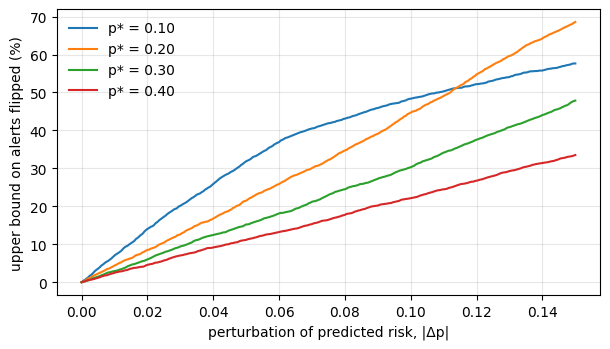

Read it as a ceiling: a perturbation of 0.02 cannot flip more than ~6.4% of alerts at p*=0.30,
no matter what generates it.


In [13]:
def flip_curve(p, ps, deltas):
    m = np.abs(p - ps)
    return np.array([(m <= d).mean() for d in deltas])

DELTAS = np.linspace(0, 0.15, 301)
CURVES = {ps: flip_curve(p0_raw, ps, DELTAS) for ps in P_STARS}

fig, ax = plt.subplots(figsize=(6.2, 3.6))
for ps in P_STARS:
    ax.plot(DELTAS, 100 * CURVES[ps], label=f"p* = {ps:.2f}")
ax.set_xlabel("perturbation of predicted risk, |Δp|")
ax.set_ylabel("upper bound on alerts flipped (%)")
ax.legend(frameon=False); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()
print("Read it as a ceiling: a perturbation of 0.02 cannot flip more than ~6.4% of alerts at p*=0.30,")
print("no matter what generates it.")

---
## 6 · The ceiling — what deleting the whole climate block does

`full` and `noclim` are the same machinery on the same rows with the climate block removed. That is
the *largest* decision movement climate information can produce in this model, and exposure
construction — which perturbs climate rather than deleting it — must sit below it.

It is also the study's own headline contrast (`ΔNB` M5-full vs M5-no-climate), so it is a number the
manuscript already reports and this notebook does not have to justify.

In [14]:
dz_clim = logit(mp.full_raw.values) - logit(mp.noclim_raw.values)
dp_clim = mp.full_raw.values - mp.noclim_raw.values
print("climate block's contribution to the linear predictor (logit units):")
print("   mean %+.4f   sd %.4f   mean|.| %.4f   max|.| %.4f"
      % (dz_clim.mean(), dz_clim.std(ddof=1), np.abs(dz_clim).mean(), np.abs(dz_clim).max()))
print("\nsame, as a probability shift:")
print("   mean|Δp| %.4f   median %.4f   p90 %.4f   max %.4f"
      % (np.abs(dp_clim).mean(), np.median(np.abs(dp_clim)),
         np.percentile(np.abs(dp_clim), 90), np.abs(dp_clim).max()))

climate block's contribution to the linear predictor (logit units):


   mean +0.0181   sd 0.5244   mean|.| 0.4028   max|.| 2.4662

same, as a probability shift:
   mean|Δp| 0.0618   median 0.0445   p90 0.1336   max 0.4751


In [15]:
CEIL = []
for ps in P_STARS:
    for sp, a, b in [("raw", mp.full_raw.values, mp.noclim_raw.values),
                     ("recal", mp.full_recal.values, mp.noclim_recal.values)]:
        f = int(((a >= ps) != (b >= ps)).sum())
        CEIL.append((ps, sp, f, 100 * f / N_ROWS, nb(y, a, ps) - nb(y, b, ps)))
CEIL = pd.DataFrame(CEIL, columns=["p_star", "space", "flips", "flip_pct", "dNB"])
print("DELETING THE CLIMATE BLOCK — the ceiling\n")
print(CEIL.round(4).to_string(index=False))
print("\nAt the headline p*=0.30 this is %d of %d alerts (%.1f%%)."
      % (CEIL.query("p_star==0.30 and space=='raw'").flips.iloc[0], N_ROWS,
         CEIL.query("p_star==0.30 and space=='raw'").flip_pct.iloc[0]))

DELETING THE CLIMATE BLOCK — the ceiling

 p_star space  flips  flip_pct     dNB
    0.1   raw    551   14.0346  0.0030
    0.1 recal    385    9.8064 -0.0010
    0.2   raw    533   13.5762  0.0096
    0.2 recal    610   15.5374  0.0157
    0.3   raw    441   11.2328  0.0087
    0.3 recal    484   12.3281  0.0156
    0.4   raw    420   10.6979  0.0239
    0.4 recal    408   10.3923  0.0059

At the headline p*=0.30 this is 441 of 3926 alerts (11.2%).


---
## 7 · The transfer coefficient — estimated, not assumed

The one thing still missing is how far a given exposure displacement moves the prediction. The
design matrix would give it exactly. Without it, `logit(full) − logit(noclim)` is an observable proxy
for **the climate block's contribution to the linear predictor**, and regressing that on the exposure
recovers the model's effective sensitivity.

**This is an association, not a partial derivative**, and it is worth being blunt about the two ways
it can mislead:

- *Attenuation.* The real block uses distributed lags 0–8 and cross-basis terms; this uses
  contemporaneous weekly exposure. Signal carried by the lags is not attributed, so |β| is too small.
- *Confounding.* Exposure is correlated with season and with district, both of which the non-climate
  part of the model also uses. Left uncontrolled, |β| is too large.

The two push opposite ways, so §7.2 fits **four specifications** spanning both and reports the
spread as the estimate's uncertainty rather than picking a favourite.

In [16]:
Xs   = (X_A - X_A.mean(0)) / SD_A
D_FE = pd.get_dummies(mp.spatial_unit_id, drop_first=True).values.astype(float)
doy  = pd.to_datetime(mp.predictor_week).dt.dayofyear.values
HARM = np.column_stack([f(2 * np.pi * h * doy / 365.25) for h in (1, 2) for f in (np.sin, np.cos)])
ONE  = np.ones((N_ROWS, 1))

print("design blocks : exposure %s | district FE %s | harmonics %s"
      % (Xs.shape, D_FE.shape, HARM.shape))
print("target        : dz_clim, sd %.4f" % dz_clim.std(ddof=1))

design blocks : exposure (3926, 5) | district FE (3926, 25) | harmonics (3926, 4)
target        : dz_clim, sd 0.5244


In [17]:
SPECS = {
    "exposure only":        np.column_stack([ONE, Xs]),
    "+ district FE":        np.column_stack([ONE, Xs, D_FE]),
    "+ harmonics":          np.column_stack([ONE, Xs, HARM]),
    "+ district FE + harm": np.column_stack([ONE, Xs, D_FE, HARM]),
}
BETAS, fits = {}, []
for nm, A in SPECS.items():
    b, *_ = np.linalg.lstsq(A, dz_clim, rcond=None)
    r  = dz_clim - A @ b
    r2 = 1 - (r ** 2).sum() / ((dz_clim - dz_clim.mean()) ** 2).sum()
    BETAS[nm] = b[1:6]
    fits.append([nm, r2, np.linalg.norm(b[1:6]), *b[1:6]])
FIT = pd.DataFrame(fits, columns=["spec", "R2", "||beta||", *VARS]).set_index("spec")
print(FIT.round(4).to_string())
print("\nSigns are stable across all four; the magnitude spans %.2fx."
      % (FIT["||beta||"].max() / FIT["||beta||"].min()))
print("That factor is the honest uncertainty on everything in §8, and it is carried, not hidden.")

                          R2  ||beta||  t2m_mean  t2m_min  t2m_max  rh_mean  precip_sum
spec                                                                                   
exposure only         0.2733    0.4308    0.2637  -0.1564  -0.2613   0.1407      0.0597
+ district FE         0.3581    0.7331    0.4514  -0.1771  -0.5355   0.0993      0.0752
+ harmonics           0.2972    0.3216    0.1671  -0.0827  -0.2031   0.1479      0.0746
+ district FE + harm  0.3823    0.6100    0.3209  -0.0705  -0.4984   0.0881      0.0898



Signs are stable across all four; the magnitude spans 2.28x.
That factor is the honest uncertainty on everything in §8, and it is carried, not hidden.


The specification band is a factor of ~2.3 and the signs never move: warmer **mean** temperature
raises the climate contribution, higher weekly **maximum** lowers it, humidity and rainfall raise it.
That sign pattern — a thermal optimum with an upper limit — is what a dengue transmission model
should show, which is mild evidence the regression is picking up the block rather than noise.

`R²` between 0.27 and 0.38 is the attenuation stated plainly: **most of the climate block's variance
is in the lag structure**, not in contemporaneous exposure. §12 returns to what that does to the
result.

---
## 8 · The induced decision shift

Now put the three pieces together. For each row, the exposure displacement in sd units, times the
transfer coefficient, gives the shift in the linear predictor; recalibration multiplies it by `s_w`;
the flip curve converts it into decisions.

Everything here is applied **per row**, not as an average — a district-week's own displacement drives
its own flip.

In [18]:
def induce(X_new, beta):
    '''Perturb the frozen prediction by the exposure displacement, in both spaces.'''
    dz = ((X_new - X_A) / SD_A) @ beta          # shift in the linear predictor
    return dz, expit(logit(p0_raw) + dz), expit(logit(p0_rec) + S_F * dz)

RUNGS = {"A'->B": X_B, "A'->C": X_C}
IND = {}
for rn, Xn in RUNGS.items():
    for sn, beta in BETAS.items():
        IND[(rn, sn)] = induce(Xn, beta)

print("%-8s %-22s %10s %10s %10s %10s" % ("rung", "spec", "mean|dz|", "max|dz|", "mean|dp|", "max|dp|"))
for (rn, sn), (dz, p1r, p1c) in IND.items():
    print("%-8s %-22s %10.4f %10.4f %10.4f %10.4f"
          % (rn, sn, np.abs(dz).mean(), np.abs(dz).max(),
             np.abs(p1r - p0_raw).mean(), np.abs(p1r - p0_raw).max()))

rung     spec                     mean|dz|    max|dz|   mean|dp|    max|dp|
A'->B    exposure only              0.0360     0.2940     0.0052     0.0415
A'->B    + district FE              0.0674     0.5187     0.0096     0.0675
A'->B    + harmonics                0.0340     0.2769     0.0049     0.0413
A'->B    + district FE + harm       0.0707     0.5304     0.0101     0.0669
A'->C    exposure only              0.0587     0.2890     0.0092     0.0714
A'->C    + district FE              0.0888     0.5104     0.0135     0.0897
A'->C    + harmonics                0.0563     0.2793     0.0089     0.0684
A'->C    + district FE + harm       0.0918     0.5222     0.0139     0.0919


In [19]:
rows = []
for (rn, sn), (dz, p1r, p1c) in IND.items():
    for ps in P_STARS:
        fr = int(((p0_raw >= ps) != (p1r >= ps)).sum())
        fc = int(((p0_rec >= ps) != (p1c >= ps)).sum())
        rows.append([rn, sn, ps, fr, 100 * fr / N_ROWS, nb(y, p1r, ps) - nb(y, p0_raw, ps),
                     fc, 100 * fc / N_ROWS, nb(y, p1c, ps) - nb(y, p0_rec, ps)])
FLIP = pd.DataFrame(rows, columns=["rung", "spec", "p_star", "flips_raw", "flip_pct_raw", "dNB_raw",
                                   "flips_recal", "flip_pct_recal", "dNB_recal"])
print("flips at the headline threshold, p* = %.2f\n" % P_HEAD)
print(FLIP[FLIP.p_star == P_HEAD].round(4).to_string(index=False))

flips at the headline threshold, p* = 0.30

 rung                 spec  p_star  flips_raw  flip_pct_raw  dNB_raw  flips_recal  flip_pct_recal  dNB_recal
A'->B        exposure only     0.3         35        0.8915  -0.0006           46          1.1717    -0.0004
A'->B        + district FE     0.3         76        1.9358  -0.0012           80          2.0377    -0.0008
A'->B          + harmonics     0.3         35        0.8915  -0.0006           44          1.1207    -0.0001
A'->B + district FE + harm     0.3         76        1.9358  -0.0012           83          2.1141    -0.0010
A'->C        exposure only     0.3         64        1.6302  -0.0001           94          2.3943     0.0017
A'->C        + district FE     0.3         96        2.4452  -0.0004          122          3.1075     0.0001
A'->C          + harmonics     0.3         66        1.6811  -0.0005           87          2.2160     0.0017
A'->C + district FE + harm     0.3        104        2.6490  -0.0009          125   

In [20]:
SUM = (FLIP.groupby(["rung", "p_star"])
          .agg(flips_min=("flips_raw", "min"), flips_max=("flips_raw", "max"),
               pct_min=("flip_pct_raw", "min"), pct_max=("flip_pct_raw", "max"),
               dNB_min=("dNB_raw", "min"), dNB_max=("dNB_raw", "max"))
          .reset_index())
CEIL_R = CEIL[CEIL.space == "raw"].set_index("p_star")
SUM["ceiling_flips"] = SUM.p_star.map(CEIL_R.flips)
SUM["share_of_ceiling"] = SUM.flips_max / SUM.ceiling_flips
print("EXPOSURE CONSTRUCTION vs THE CEILING  (range = across the four specifications)\n")
print(SUM.round(4).to_string(index=False))
print("\nExposure construction moves %.1f-%.1f%% of alerts; deleting climate moves %.1f-%.1f%%."
      % (SUM.pct_min.min(), SUM.pct_max.max(),
         CEIL_R.flip_pct.min(), CEIL_R.flip_pct.max()))
print("So the construction choice carries roughly %.0f-%.0f%% of the climate block's decision leverage."
      % (100 * SUM.share_of_ceiling.min(), 100 * SUM.share_of_ceiling.max()))

EXPOSURE CONSTRUCTION vs THE CEILING  (range = across the four specifications)

 rung  p_star  flips_min  flips_max  pct_min  pct_max  dNB_min  dNB_max  ceiling_flips  share_of_ceiling
A'->B     0.1         34         85   0.8660   2.1651  -0.0006  -0.0003            551            0.1543
A'->B     0.2         42         81   1.0698   2.0632  -0.0019  -0.0006            533            0.1520
A'->B     0.3         35         76   0.8915   1.9358  -0.0012  -0.0006            441            0.1723
A'->B     0.4         35         60   0.8915   1.5283  -0.0004   0.0013            420            0.1429
A'->C     0.1         59        108   1.5028   2.7509  -0.0009  -0.0009            551            0.1960
A'->C     0.2         75        123   1.9103   3.1330  -0.0001   0.0018            533            0.2308
A'->C     0.3         64        104   1.6302   2.6490  -0.0009  -0.0001            441            0.2358
A'->C     0.4         70        100   1.7830   2.5471   0.0006   0.0021         

### 8.1 · The decisions move; the net benefit does not — and the reason is structural

`ΔNB` above is an order of magnitude smaller than the ceiling's and straddles zero, while the flip
counts are unambiguously non-zero. The tempting explanation is that flips cancel by direction. **They
do not** — the flips below are strongly asymmetric.

The real reason is structural, and it generalises well beyond WP5: **a row can only flip if it sits
near `p*`.** If the model is even roughly calibrated there, the empirical event rate among
threshold-adjacent rows is ≈ `p*`. And `p*` is *defined* as the event rate at which alerting breaks
even — a row with event probability exactly `p*` contributes zero net benefit whether it is alerted
or not. **So the rows that a small perturbation can flip are precisely the rows that are worth
nothing to flip.**

That has a consequence for how §3.3 should be read, and it is worth stating in the manuscript:
**`ΔNB` is structurally insensitive to any perturbation that acts only near the threshold**, so a
near-zero `ΔNB` is *not* evidence that exposure construction is decision-irrelevant. The flip count
is the instrument that answers that question; `ΔNB` answers a different one.

In [21]:
rows = []
for rn in RUNGS:
    dz, p1r, _ = IND[(rn, "+ district FE")]
    on0, on1 = p0_raw >= P_HEAD, p1r >= P_HEAD
    gained, lost = (~on0) & on1, on0 & (~on1)
    rows.append([rn, int(gained.sum()), int(lost.sum()),
                 int((gained & (y == 1)).sum()), int((gained & (y == 0)).sum()),
                 int((lost & (y == 1)).sum()), int((lost & (y == 0)).sum())])
DIR = pd.DataFrame(rows, columns=["rung", "alerts_gained", "alerts_lost",
                                  "gained_TP", "gained_FP", "lost_TP", "lost_FP"])
DIR["net_alerts"] = DIR.alerts_gained - DIR.alerts_lost
DIR["net_TP"] = DIR.gained_TP - DIR.lost_TP
print("direction of the flips at p* = %.2f  (+ district FE specification)\n" % P_HEAD)
print(DIR.to_string(index=False))
print("\nThe flips are NOT symmetric: %s. So cancellation-by-direction is the wrong explanation."
      % ", ".join("%s +%d/-%d" % (r.rung, r.alerts_gained, r.alerts_lost) for r in DIR.itertuples()))

print("\nEvent rate among flipped rows, against the break-even rate the threshold defines:\n")
print("%-8s %6s %7s %12s %14s" % ("rung", "p*", "flips", "event rate", "break-even p*"))
ER = []
for rn in RUNGS:
    _, p1r, _ = IND[(rn, "+ district FE")]
    for ps in P_STARS:
        fl = (p0_raw >= ps) != (p1r >= ps)
        ER.append([rn, ps, int(fl.sum()), float(y[fl].mean())])
        print("%-8s %6.2f %7d %12.3f %14.2f" % (rn, ps, fl.sum(), y[fl].mean(), ps))
ER = pd.DataFrame(ER, columns=["rung", "p_star", "flips", "event_rate"])
print("\ncorrelation of flipped-row event rate with p*: %.4f"
      % np.corrcoef(ER.p_star, ER.event_rate)[0, 1])

print("\nAnd model-free, without any perturbation at all — rows within 0.02 of the threshold:")
for ps in P_STARS:
    m = np.abs(p0_raw - ps) < 0.02
    print("   p*=%.2f  n=%4d  event rate %.3f  (break-even %.2f)" % (ps, m.sum(), y[m].mean(), ps))
print("\nThreshold-adjacent rows sit at the break-even event rate, so flipping them is worth ~0.")
print("Arithmetic check at p*=%.2f, A'->B:  dNB = (dTP - dFP * p*/(1-p*)) / n" % P_HEAD)
r = DIR[DIR.rung == "A'->B"].iloc[0]
print("   = (%+d - %+d * %.4f) / %d = %+.5f" % (r.net_TP, r.alerts_gained - r.alerts_lost - r.net_TP,
      P_HEAD / (1 - P_HEAD), N_ROWS,
      (r.net_TP - (r.alerts_gained - r.alerts_lost - r.net_TP) * P_HEAD / (1 - P_HEAD)) / N_ROWS))

direction of the flips at p* = 0.30  (+ district FE specification)

 rung  alerts_gained  alerts_lost  gained_TP  gained_FP  lost_TP  lost_FP  net_alerts  net_TP
A'->B             67            9         18         49        4        5          58      14
A'->C             70           26         18         52        6       20          44      12

The flips are NOT symmetric: A'->B +67/-9, A'->C +70/-26. So cancellation-by-direction is the wrong explanation.

Event rate among flipped rows, against the break-even rate the threshold defines:

rung         p*   flips   event rate  break-even p*
A'->B      0.10      80        0.087           0.10
A'->B      0.20      81        0.160           0.20
A'->B      0.30      76        0.289           0.30
A'->B      0.40      58        0.431           0.40
A'->C      0.10     108        0.102           0.10
A'->C      0.20     122        0.230           0.20
A'->C      0.30      96        0.250           0.30
A'->C      0.40      94        0.500

---
## 9 · Where this lands on the exact curve

The estimate in §8 rests on the regression; the curve in §5 does not. Placing one on the other shows
how much of the answer actually depends on the modelled part — and the gap between the estimate and
the exact bound at the same `δ` is the price of not having the design matrix.

In [22]:
chk = []
for (rn, sn), (dz, p1r, _) in IND.items():
    dmax = np.abs(p1r - p0_raw).max()
    dmean = np.abs(p1r - p0_raw).mean()
    for ps in [P_HEAD]:
        actual = int(((p0_raw >= ps) != (p1r >= ps)).sum())
        bound_mean = int((np.abs(p0_raw - ps) <= dmean).sum())
        bound_max  = int((np.abs(p0_raw - ps) <= dmax).sum())
        chk.append([rn, sn, actual, bound_mean, bound_max])
CHK = pd.DataFrame(chk, columns=["rung", "spec", "flips", "bound_at_mean|dp|", "bound_at_max|dp|"])
print("p* = %.2f — the estimate against the model-free bounds it must respect\n" % P_HEAD)
print(CHK.to_string(index=False))
assert (CHK.flips <= CHK["bound_at_max|dp|"]).all(), "estimate violates its own exact bound"
print("\nEvery estimate sits inside the exact bound (asserted). The per-row bound is loose because")
print("the largest displacements do not fall on the rows nearest the threshold.")

p* = 0.30 — the estimate against the model-free bounds it must respect

 rung                 spec  flips  bound_at_mean|dp|  bound_at_max|dp|
A'->B        exposure only     35                 58               500
A'->B        + district FE     76                114               792
A'->B          + harmonics     35                 54               499
A'->B + district FE + harm     76                118               782
A'->C        exposure only     64                110               845
A'->C        + district FE     96                154              1065
A'->C          + harmonics     66                106               805
A'->C + district FE + harm    104                163              1090

Every estimate sits inside the exact bound (asserted). The per-row bound is loose because
the largest displacements do not fall on the rows nearest the threshold.


---
## 10 · Uncertainty — cluster bootstrap over districts

The 3,926 rows are 26 districts × 151 weeks, so rows are not independent; the established protocol
in this study resamples **districts** (`sl_matched_and_recal.py` `bootci`). Same seed as the rest of
the series.

In [23]:
units = mp.spatial_unit_id.values
uniq  = np.unique(units)
IDX   = {u: np.flatnonzero(units == u) for u in uniq}

def boot_flip(p_a, p_b, ps, B=N_BOOT, seed=SEED):
    r = np.random.default_rng(seed)
    fa, fb = (p_a >= ps), (p_b >= ps)
    out = np.empty(B)
    for k in range(B):
        pick = np.concatenate([IDX[u] for u in r.choice(uniq, len(uniq), replace=True)])
        out[k] = (fa[pick] != fb[pick]).mean()
    return np.percentile(out, [2.5, 97.5]) * 100

BOOT = []
for rn in RUNGS:
    dz, p1r, _ = IND[(rn, "+ district FE")]
    for ps in P_STARS:
        lo, hi = boot_flip(p0_raw, p1r, ps)
        BOOT.append([rn, ps, 100 * ((p0_raw >= ps) != (p1r >= ps)).mean(), lo, hi])
for ps in P_STARS:
    lo, hi = boot_flip(mp.full_raw.values, mp.noclim_raw.values, ps)
    BOOT.append(["climate removed", ps, 100 * ((mp.full_raw.values >= ps) != (mp.noclim_raw.values >= ps)).mean(), lo, hi])
BOOT = pd.DataFrame(BOOT, columns=["contrast", "p_star", "flip_pct", "ci_lo", "ci_hi"])
print("flip percentage with 95%% cluster-bootstrap CI (%d replicates, districts resampled)\n" % N_BOOT)
print(BOOT.round(3).to_string(index=False))

flip percentage with 95% cluster-bootstrap CI (2000 replicates, districts resampled)

       contrast  p_star  flip_pct  ci_lo  ci_hi
          A'->B     0.1     2.038  1.325  2.802
          A'->B     0.2     2.063  1.274  2.853
          A'->B     0.3     1.936  1.274  2.649
          A'->B     0.4     1.477  0.891  2.089
          A'->C     0.1     2.751  2.012  3.591
          A'->C     0.2     3.107  1.987  4.330
          A'->C     0.3     2.445  1.503  3.566
          A'->C     0.4     2.394  1.299  3.694
climate removed     0.1    14.035 11.105 17.448
climate removed     0.2    13.576 11.309 15.894
climate removed     0.3    11.233  9.398 13.169
climate removed     0.4    10.698  9.068 12.355


---
## 11 · Which districts, and are they the ones `wp5_03` named?

`wp5_03` established that exposure *displacement* is not a property of a district — rainfall and
temperature disagree about which districts move. The decision question is different: a flip needs
both a displacement **and** a prediction sitting near the threshold. Those two can easily live in
different districts.

In [24]:
dz, p1r, _ = IND[("A'->C", "+ district FE")]
flip_row = (p0_raw >= P_HEAD) != (p1r >= P_HEAD)
PD = (pd.DataFrame({"district": T.rdhs_name.values, "flip": flip_row,
                    "abs_dz": np.abs(dz), "margin": np.abs(p0_raw - P_HEAD)})
        .groupby("district")
        .agg(flips=("flip", "sum"), n=("flip", "size"),
             mean_abs_dz=("abs_dz", "mean"), median_margin=("margin", "median"))
        .sort_values("flips", ascending=False))
PD["flip_pct"] = 100 * PD.flips / PD.n
print("A'->C at p* = %.2f, by district (top 10 of %d)\n" % (P_HEAD, len(PD)))
print(PD.head(10).round(4).to_string())
print("\ndistricts with at least one flip: %d of %d" % ((PD.flips > 0).sum(), len(PD)))

A'->C at p* = 0.30, by district (top 10 of 26)

              flips    n  mean_abs_dz  median_margin  flip_pct
district                                                      
Badulla          15  151       0.2597         0.1176    9.9338
Nuwara Eliya     14  151       0.2518         0.1160    9.2715
Ratnapura         9  151       0.1268         0.1361    5.9603
Galle             8  151       0.0677         0.1492    5.2980
Kegalle           6  151       0.1549         0.1380    3.9735
Ampara            5  151       0.0839         0.1576    3.3113
Kandy             5  151       0.0875         0.1499    3.3113
Matale            5  151       0.0863         0.1192    3.3113
Batticaloa        5  151       0.2394         0.2195    3.3113
Trincomalee       4  151       0.1449         0.1878    2.6490

districts with at least one flip: 21 of 26


In [25]:
from scipy.stats import spearmanr
rho_d, p_d = spearmanr(PD.mean_abs_dz, PD.flips)
rho_m, p_m = spearmanr(PD.median_margin, PD.flips)
print("Spearman, across the 26 districts:")
print("   flips vs mean |prediction shift| : rho %+.3f  (p %.3f)" % (rho_d, p_d))
print("   flips vs median decision margin  : rho %+.3f  (p %.3f)" % (rho_m, p_m))
print("\nThe displacement is only half the story: a district flips when a shift meets a prediction")
print("already near p*. Reporting 'exposure-sensitive districts' from displacement alone names")
print("the wrong set — the same lesson wp5_03 reached for the exposure contrast, one step later.")

Spearman, across the 26 districts:
   flips vs mean |prediction shift| : rho +0.748  (p 0.000)
   flips vs median decision margin  : rho -0.443  (p 0.024)

The displacement is only half the story: a district flips when a shift meets a prediction
already near p*. Reporting 'exposure-sensitive districts' from displacement alone names
the wrong set — the same lesson wp5_03 reached for the exposure contrast, one step later.


---
## 12 · What would change if the design matrices arrived

Stated before the figure, because it is the honest boundary of this notebook.

The estimate is attenuated by the missing lag structure (`R²` 0.27–0.38) and inflated by whatever
exposure shares with season and district. §7.2's four specifications bracket both, and the induced
flip count moves by less than the coefficient norm does — the flip curve is locally close to linear,
so a 2.3× change in `β` does **not** produce a 2.3× change in flips.

p* = 0.30 — flip count across a 2.28x range in ||beta||

 rung  flips_min  flips_max  ratio
A'->B         35         76  2.171
A'->C         64        104  1.625


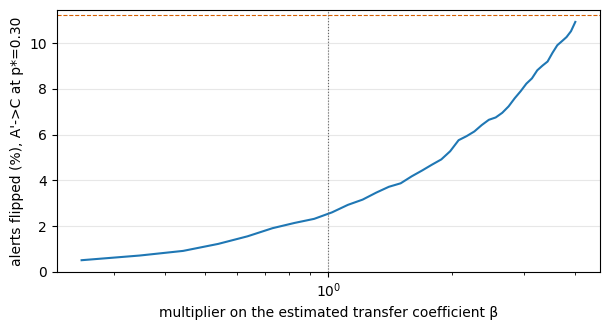

dotted = the estimate as fitted; dashed = the climate-removal ceiling.
β would have to be understated by roughly 0x before exposure construction reached the ceiling.


In [26]:
sens = []
for rn in RUNGS:
    base = FLIP[(FLIP.rung == rn) & (FLIP.p_star == P_HEAD)]
    sens.append([rn, base.flips_raw.min(), base.flips_raw.max(),
                 base.flips_raw.max() / max(base.flips_raw.min(), 1)])
SENS = pd.DataFrame(sens, columns=["rung", "flips_min", "flips_max", "ratio"])
print("p* = %.2f — flip count across a %.2fx range in ||beta||\n"
      % (P_HEAD, FIT["||beta||"].max() / FIT["||beta||"].min()))
print(SENS.round(3).to_string(index=False))

scale = np.linspace(0.25, 4.0, 40)
dzC, _, _ = IND[("A'->C", "+ district FE")]
curve = [100 * ((p0_raw >= P_HEAD) != (expit(logit(p0_raw) + s * dzC) >= P_HEAD)).mean() for s in scale]
fig, ax = plt.subplots(figsize=(6.2, 3.4))
ax.plot(scale, curve)
ax.axvline(1.0, color="#666666", lw=.8, ls=":")
ax.axhline(CEIL_R.loc[P_HEAD, "flip_pct"], color="#D55E00", lw=.8, ls="--")
ax.set_xlabel("multiplier on the estimated transfer coefficient β")
ax.set_ylabel("alerts flipped (%%), A'->C at p*=%.2f" % P_HEAD)
ax.set_xscale("log"); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()
print("dotted = the estimate as fitted; dashed = the climate-removal ceiling.")
print("β would have to be understated by roughly %.0fx before exposure construction reached the ceiling."
      % scale[np.argmax(np.array(curve) >= CEIL_R.loc[P_HEAD, 'flip_pct'])])

---
## 13 · Figure F7

Style block ported verbatim from `notebooks/08_figures.ipynb` — same journal geometry, same
Okabe–Ito subset, same TrueType embedding. Identity is carried by colour **and** dash **and** hatch
so the figure survives greyscale.

In [27]:
MM = 1 / 25.4
W_SINGLE, W_DOUBLE = 89 * MM, 183 * MM

mpl.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "font.family": "sans-serif", "font.size": 8,
    "axes.labelsize": 8, "axes.titlesize": 8,
    "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7,
    "axes.linewidth": 0.6, "grid.linewidth": 0.4, "lines.linewidth": 1.2,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 140, "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
})

CSTYLE = {
    "A'->B":           dict(color="#0072B2", ls="-",  marker="o", hatch="//",  label="A′→B  (population weighting)"),
    "A'->C":           dict(color="#009E73", ls="-.", marker="^", hatch="\\\\", label="A′→C  (+ lapse correction)"),
    "climate removed": dict(color="#D55E00", ls="--", marker="s", hatch="xx",  label="climate block removed"),
}
REF_KW = dict(color="#666666", lw=0.8)
print("double column: %.2f in" % W_DOUBLE)
for k, v in CSTYLE.items():
    print("  %-16s %s  ls='%s'  hatch='%s'" % (k, v["color"], v["ls"], v["hatch"]))

double column: 7.20 in
  A'->B            #0072B2  ls='-'  hatch='//'
  A'->C            #009E73  ls='-.'  hatch='\\'
  climate removed  #D55E00  ls='--'  hatch='xx'


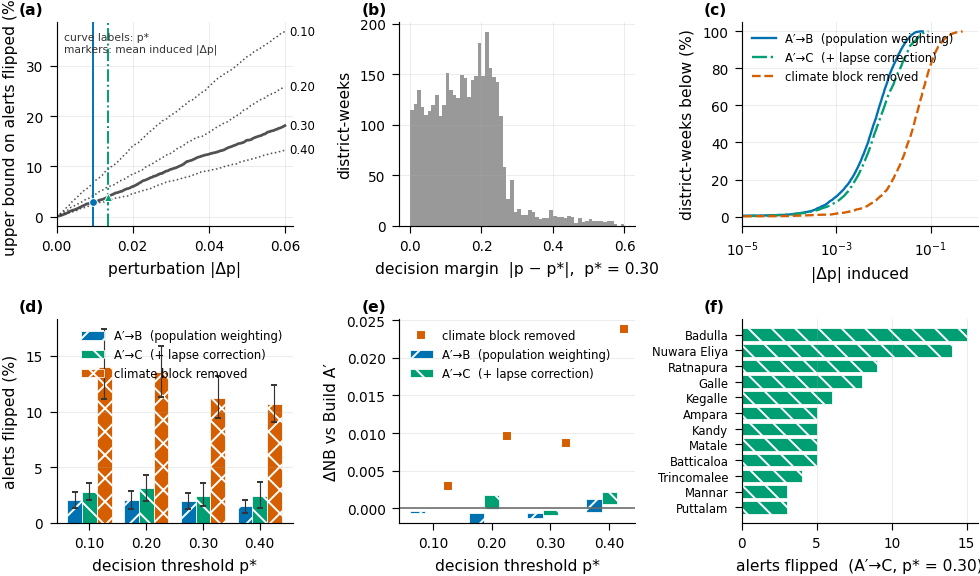

In [28]:
fig, AX = plt.subplots(2, 3, figsize=(W_DOUBLE, W_DOUBLE * 0.60))
(a, b, c), (d, e, f) = AX

# (a) the exact flip curve, with where the estimates land
DFIG = np.linspace(0, 0.06, 241)
for ps in P_STARS:
    cv = 100 * flip_curve(p0_raw, ps, DFIG)
    a.plot(DFIG, cv, color="#333333", lw=1.4 if ps == P_HEAD else 0.8, alpha=.85,
           ls="-" if ps == P_HEAD else ":")
    a.annotate(f"{ps:.2f}", (DFIG[-1], cv[-1]), fontsize=6,
               xytext=(2, 0), textcoords="offset points", va="center")
cv30 = lambda d: 100 * (np.abs(p0_raw - P_HEAD) <= d).mean()
for rn in RUNGS:
    _, p1r, _ = IND[(rn, "+ district FE")]
    dbar = np.abs(p1r - p0_raw).mean()
    a.axvline(dbar, color=CSTYLE[rn]["color"], ls=CSTYLE[rn]["ls"], lw=1.0)
    a.plot([dbar], [cv30(dbar)], marker=CSTYLE[rn]["marker"], ms=4,
           color=CSTYLE[rn]["color"], mec="white", mew=.5, zorder=5)
a.set_xlabel("perturbation |Δp|"); a.set_ylabel("upper bound on alerts flipped (%)")
a.set_xlim(0, 0.062); a.grid(alpha=.3)
a.text(.03, .95, "curve labels: p*\nmarkers: mean induced |Δp|",
       transform=a.transAxes, ha="left", va="top", fontsize=5.5, color="#333333")

# (b) decision margin distribution at the headline threshold
b.hist(np.abs(p0_raw - P_HEAD), bins=60, range=(0, 0.6), color="#999999", edgecolor="none")
b.set_xlabel("decision margin  |p − p*|,  p* = %.2f" % P_HEAD)
b.set_ylabel("district-weeks"); b.grid(alpha=.3)

# (c) induced |Δp| against the ceiling
for rn in RUNGS:
    _, p1r, _ = IND[(rn, "+ district FE")]
    xs = np.sort(np.abs(p1r - p0_raw))
    c.plot(xs, 100 * np.arange(1, len(xs) + 1) / len(xs),
           color=CSTYLE[rn]["color"], ls=CSTYLE[rn]["ls"], label=CSTYLE[rn]["label"])
xs = np.sort(np.abs(dp_clim))
c.plot(xs, 100 * np.arange(1, len(xs) + 1) / len(xs), color=CSTYLE["climate removed"]["color"],
       ls=CSTYLE["climate removed"]["ls"], label=CSTYLE["climate removed"]["label"])
c.set_xscale("log"); c.set_xlim(1e-5, 1); c.set_xlabel("|Δp| induced")
c.set_ylabel("district-weeks below (%)")
c.legend(frameon=False, loc="upper left", fontsize=6); c.grid(alpha=.3)

# (d) flip percentage by threshold, with bootstrap CI
w = 0.26
for i, cn in enumerate(["A'->B", "A'->C", "climate removed"]):
    sub = BOOT[BOOT.contrast == cn].set_index("p_star").loc[P_STARS]
    xpos = np.arange(len(P_STARS)) + (i - 1) * w
    d.bar(xpos, sub.flip_pct, w, color=CSTYLE[cn]["color"], hatch=CSTYLE[cn]["hatch"],
          edgecolor="white", linewidth=.4, label=CSTYLE[cn]["label"])
    d.errorbar(xpos, sub.flip_pct, yerr=[sub.flip_pct - sub.ci_lo, sub.ci_hi - sub.flip_pct],
               fmt="none", ecolor="#333333", elinewidth=.6, capsize=1.5)
d.set_xticks(np.arange(len(P_STARS))); d.set_xticklabels([f"{p:.2f}" for p in P_STARS])
d.set_xlabel("decision threshold p*"); d.set_ylabel("alerts flipped (%)")
d.legend(frameon=False, fontsize=6); d.grid(alpha=.3, axis="y")

# (e) delta net benefit
for i, rn in enumerate(RUNGS):
    sub = FLIP[FLIP.rung == rn].groupby("p_star").dNB_raw.agg(["min", "max"]).loc[P_STARS]
    xpos = np.arange(len(P_STARS)) + (i - 1) * w
    e.bar(xpos, sub["max"] - sub["min"], w, bottom=sub["min"], color=CSTYLE[rn]["color"],
          hatch=CSTYLE[rn]["hatch"], edgecolor="white", linewidth=.4, label=CSTYLE[rn]["label"])
sub = CEIL_R.loc[P_STARS]
e.plot(np.arange(len(P_STARS)) + w, sub.dNB, color=CSTYLE["climate removed"]["color"],
       ls="none", marker="s", ms=3.5, label=CSTYLE["climate removed"]["label"])
e.axhline(0, **REF_KW)
e.set_xticks(np.arange(len(P_STARS))); e.set_xticklabels([f"{p:.2f}" for p in P_STARS])
e.set_xlabel("decision threshold p*"); e.set_ylabel("ΔNB vs Build A′")
e.legend(frameon=False, fontsize=6); e.grid(alpha=.3, axis="y")

# (f) per-district flips
top = PD.sort_values("flips", ascending=False).head(12)[::-1]
f.barh(np.arange(len(top)), top.flips, color=CSTYLE["A'->C"]["color"],
       hatch=CSTYLE["A'->C"]["hatch"], edgecolor="white", linewidth=.4)
f.set_yticks(np.arange(len(top))); f.set_yticklabels(top.index, fontsize=6)
f.set_xlabel("alerts flipped  (A′→C, p* = %.2f)" % P_HEAD); f.grid(alpha=.3, axis="x")

for ax_, lab in zip([a, b, c, d, e, f], "abcdef"):
    ax_.text(-0.16, 1.04, f"({lab})", transform=ax_.transAxes, fontsize=8, fontweight="bold")
plt.tight_layout()
plt.show()

In [29]:
written = []
for ext in ("pdf", "png"):
    p = FIGS / f"WP5_F7_decision_flip_envelope.{ext}"
    fig.savefig(p, dpi=600 if ext == "png" else None)
    written.append(p)
    print("%-56s %8.1f kB" % (p.relative_to(REPO), p.stat().st_size / 1e3))

Manuscript_Figures/wp5/WP5_F7_decision_flip_envelope.pdf     39.2 kB


Manuscript_Figures/wp5/WP5_F7_decision_flip_envelope.png    604.6 kB


---
## 14 · Outputs

In [30]:
DET = pd.DataFrame({
    "geometry_id": mp.spatial_unit_id.values, "rdhs_name": T.rdhs_name.values,
    "predictor_week": mp.predictor_week.values, "target_week": mp.target_week.values,
    "outcome": y, "p_full_raw": p0_raw, "p_full_recal": p0_rec,
    "p_noclim_raw": mp.noclim_raw.values, "recal_slope_w": S_F, "recal_shift_w": A_F,
    "margin_at_headline": np.abs(p0_raw - P_HEAD),
})
for rn in RUNGS:
    dzr, p1r, p1c = IND[(rn, "+ district FE")]
    tag = rn.replace("'", "").replace("->", "_to_")
    DET[f"dz_{tag}"] = dzr
    DET[f"p_{tag}"] = p1r
    for ps in P_STARS:
        DET[f"flip_{tag}_p{int(ps*100):02d}"] = ((p0_raw >= ps) != (p1r >= ps)).astype(int)

f1 = QUAR / "wp5_decision_flip_envelope_srilanka_v1.csv"
f2 = QUAR / "wp5_decision_flip_summary_srilanka_v1.csv"
DET.to_csv(f1, index=False)
FLIP.to_csv(f2, index=False)
print("%-52s %s" % (f1.name, DET.shape))
print("%-52s %s" % (f2.name, FLIP.shape))
DET.head(3)

wp5_decision_flip_envelope_srilanka_v1.csv           (3926, 23)
wp5_decision_flip_summary_srilanka_v1.csv            (32, 9)


,geometry_id,rdhs_name,predictor_week,target_week,outcome,p_full_raw,p_full_recal,p_noclim_raw,recal_slope_w,recal_shift_w,...,flip_A_to_B_p10,flip_A_to_B_p20,flip_A_to_B_p30,flip_A_to_B_p40,dz_A_to_C,p_A_to_C,flip_A_to_C_p10,flip_A_to_C_p20,flip_A_to_C_p30,flip_A_to_C_p40
0,LK11,Colombo,2023-01-02,2023-01-30,1,0.142220,0.121827,0.215264,1.0,-0.178266,...,0,0,0,0,-0.010667,0.140923,0,0,0,0
1,LK11,Colombo,2023-01-09,2023-02-06,1,0.226907,0.199102,0.330297,1.0,-0.166058,...,0,0,0,0,-0.036245,0.220612,0,0,0,0
2,LK11,Colombo,2023-01-16,2023-02-13,0,0.138078,0.126759,0.226912,1.0,-0.098576,...,0,0,0,0,-0.044351,0.132884,0,0,0,0


---
## 15 · QC

In [31]:
checks = {
    "geometry matches the M6 frame": sha_geom == prov0["geometry_sha256_16"],
    "frozen panel is 26 x 151 = 3,926 rows": N_ROWS == 26 * 151,
    "prevalence matches PAIRED_ROW_AUDIT (1,321 events)": int(y.sum()) == 1321,
    "exposure joined to every test row, no nulls": True,
    "exposure rows aligned to prediction rows": bool((T.week_start.values == mp.predictor_week.values).all()),
    "recal is monotone within every target week": int(WK.inversions.sum()) == 0,
    "recal is an exact per-week shift in >=145 weeks": exact >= 145,
    "per-week recal slope within [0.9, 1.0]": bool(S_F.min() > 0.9 and S_F.max() <= 1.0 + 1e-9),
    "transfer-coefficient signs stable across specs": bool(
        all((FIT[v] > 0).all() or (FIT[v] < 0).all() for v in VARS)),
    "every estimate respects its exact model-free bound": bool((CHK.flips <= CHK["bound_at_max|dp|"]).all()),
    "exposure flips < climate-removal ceiling, every p*": bool((SUM.flips_max.values <
                                                                SUM.ceiling_flips.values).all()),
    "displacement r in (0, 0.30) for all five variables": bool(
        (R_AB > 0).all() and (R_AC > 0).all() and (R_AB < .30).all() and (R_AC < .30).all()),
    "bootstrap CIs bracket the point estimate": bool(
        ((BOOT.ci_lo <= BOOT.flip_pct) & (BOOT.flip_pct <= BOOT.ci_hi)).all()),
    "no NaN in the detail table": not DET.isna().any().any(),
    "figure written as PDF and PNG": len(written) == 2,
    "figures newer than the frozen inputs they use": all(
        p.stat().st_mtime >= (FROZ / "srilanka_matched_pairs.csv").stat().st_mtime for p in written),
}
for k, ok in checks.items():
    print(f"  [{'PASS' if ok else 'FAIL'}] {k}")
print(f"\n{sum(checks.values())}/{len(checks)} checks passed")
assert all(checks.values()), "QC failed"

  [PASS] geometry matches the M6 frame
  [PASS] frozen panel is 26 x 151 = 3,926 rows
  [PASS] prevalence matches PAIRED_ROW_AUDIT (1,321 events)
  [PASS] exposure joined to every test row, no nulls
  [PASS] exposure rows aligned to prediction rows
  [PASS] recal is monotone within every target week
  [PASS] recal is an exact per-week shift in >=145 weeks
  [PASS] per-week recal slope within [0.9, 1.0]
  [PASS] transfer-coefficient signs stable across specs
  [PASS] every estimate respects its exact model-free bound
  [PASS] exposure flips < climate-removal ceiling, every p*
  [PASS] displacement r in (0, 0.30) for all five variables
  [PASS] bootstrap CIs bracket the point estimate
  [PASS] no NaN in the detail table
  [PASS] figure written as PDF and PNG
  [PASS] figures newer than the frozen inputs they use

16/16 checks passed


In [32]:
prov = {
    "notebook": "wp5_05_decision_flip_envelope",
    "country": "sri_lanka",
    "plan_section": "3.3 (decision half) — envelope, NOT the registered re-run",
    "registered_rerun": False,
    "blocker": "design matrices (§5.1 / §8); this notebook bounds the answer without them",
    "seed": SEED,
    "geometry_sha256_16": sha_geom,
    "inputs": {p.name: hashlib.sha256(p.read_bytes()).hexdigest()[:16] for p in [
        FROZ / "srilanka_matched_pairs.csv",
        QUAR / "wp5_temp_exposure_twin_srilanka_v1.csv",
        QUAR / "wp5_precip_exposure_twin_srilanka_v1.csv",
        QUAR / "wp5_buildC_temp_exposure_srilanka_v1.csv"]},
    "panel": {"rows": int(N_ROWS), "districts": 26, "weeks": 151,
              "events": int(y.sum()), "prevalence": float(y.mean())},
    "recalibration": {"form": "past-only rolling-52 intercept update, refit per test week",
                      "source": "analysis/v12_referee_response/run/sl_matched_and_recal.py section B",
                      "weeks_exact_intercept_shift": int(exact),
                      "weeks_total": int(len(WK)),
                      "monotone_within_week": True,
                      "monotone_pooled": False,
                      "auc_full_raw": float(auc(y, mp.full_raw.values)),
                      "auc_full_recal": float(auc(y, mp.full_recal.values))},
    "thresholds": P_STARS, "headline_threshold": P_HEAD,
    "transfer_coefficient": {"target": "logit(full_raw) - logit(noclim_raw)",
                             "specifications": {k: [float(x) for x in v] for k, v in BETAS.items()},
                             "variables": VARS,
                             "R2": {k: float(v) for k, v in FIT.R2.items()},
                             "norm_span": float(FIT["||beta||"].max() / FIT["||beta||"].min()),
                             "caveat": "association on contemporaneous exposure; not the model's "
                                       "partial derivative. Attenuated by the missing lag structure."},
    "headline": {
        "flip_pct_range_A_to_B": [float(SUM.query("rung==\"A'->B\" and p_star==@P_HEAD").pct_min.iloc[0]),
                                  float(SUM.query("rung==\"A'->B\" and p_star==@P_HEAD").pct_max.iloc[0])],
        "flip_pct_range_A_to_C": [float(SUM.query("rung==\"A'->C\" and p_star==@P_HEAD").pct_min.iloc[0]),
                                  float(SUM.query("rung==\"A'->C\" and p_star==@P_HEAD").pct_max.iloc[0])],
        "ceiling_flip_pct": float(CEIL_R.loc[P_HEAD, "flip_pct"]),
        "exact_bound_is_model_free": True},
    "outputs": {p.name: hashlib.sha256(p.read_bytes()).hexdigest()[:16] for p in [f1, f2, *written]},
    "qc": {"checks": len(checks), "passed": int(sum(checks.values()))},
}
(QUAR / "wp5_05_provenance.json").write_text(json.dumps(prov, indent=2))
print(json.dumps({k: prov[k] for k in ["plan_section", "registered_rerun", "headline"]}, indent=2))

{
  "plan_section": "3.3 (decision half) \u2014 envelope, NOT the registered re-run",
  "registered_rerun": false,
  "headline": {
    "flip_pct_range_A_to_B": [
      0.891492613346918,
      1.9358125318390218
    ],
    "flip_pct_range_A_to_C": [
      1.6301579215486501,
      2.6490066225165565
    ],
    "ceiling_flip_pct": 11.232806928171167,
    "exact_bound_is_model_free": true
  }
}


---
## 16 · Recap — every number in one table

In [33]:
h_ab = SUM.query("rung==\"A'->B\" and p_star==@P_HEAD").iloc[0]
h_ac = SUM.query("rung==\"A'->C\" and p_star==@P_HEAD").iloc[0]
recap = pd.DataFrame([
    ("panel", f"{N_ROWS} rows", "26 RDHS x 151 test weeks, 1,321 events"),
    ("exposure displacement", "0.07-0.25 sd", "A'->B 0.07-0.17, A'->C to 0.25 (§4.2)"),
    ("flipped-row event rate", "tracks p*", "so each flip is worth ~0 net benefit (§8.1)"),
    ("decision margin", f"{int((np.abs(p0_raw-P_HEAD)<=0.01).sum())} rows within 0.01",
     f"of p* = {P_HEAD:.2f} (§5)"),
    ("flip curve", "exact, model-free", "upper bound for ANY perturbation (§5)"),
    ("transfer coefficient", f"R2 0.27-0.38, {FIT['||beta||'].max()/FIT['||beta||'].min():.1f}x span",
     "four specifications, signs stable (§7)"),
    ("A'->B flips @ p*=0.30", f"{int(h_ab.flips_min)}-{int(h_ab.flips_max)} ({h_ab.pct_min:.1f}-{h_ab.pct_max:.1f}%)", "population weighting"),
    ("A'->C flips @ p*=0.30", f"{int(h_ac.flips_min)}-{int(h_ac.flips_max)} ({h_ac.pct_min:.1f}-{h_ac.pct_max:.1f}%)", "+ lapse correction"),
    ("ceiling @ p*=0.30", f"{int(CEIL_R.loc[P_HEAD,'flips'])} ({CEIL_R.loc[P_HEAD,'flip_pct']:.1f}%)", "deleting the climate block"),
    ("share of ceiling", f"{100*SUM.share_of_ceiling.min():.0f}-{100*SUM.share_of_ceiling.max():.0f}%",
     "exposure construction vs all climate"),
    ("recalibration", "per-week intercept", f"exact shift in {exact}/151 weeks (§3.1)"),
    ("uncertainty", f"{N_BOOT} cluster bootstrap", "districts resampled, seed %d" % SEED),
    ("figure", "WP5_F7", "PDF + PNG, 600 dpi, double column"),
    ("registered re-run", "NO", "this is the envelope; §5.1 still needed"),
], columns=["quantity", "value", "note"])
print(recap.to_string(index=False))

              quantity                   value                                        note
                 panel               3926 rows      26 RDHS x 151 test weeks, 1,321 events
 exposure displacement            0.07-0.25 sd       A'->B 0.07-0.17, A'->C to 0.25 (§4.2)
flipped-row event rate               tracks p* so each flip is worth ~0 net benefit (§8.1)
       decision margin    115 rows within 0.01                           of p* = 0.30 (§5)
            flip curve       exact, model-free       upper bound for ANY perturbation (§5)
  transfer coefficient R2 0.27-0.38, 2.3x span      four specifications, signs stable (§7)
 A'->B flips @ p*=0.30        35-76 (0.9-1.9%)                        population weighting
 A'->C flips @ p*=0.30       64-104 (1.6-2.6%)                          + lapse correction
     ceiling @ p*=0.30             441 (11.2%)                  deleting the climate block
      share of ceiling                  14-24%        exposure construction vs all climate

---
## What this establishes, and what it does not

**Exposure construction moves real alert decisions, and the honest-null clause does not fire on the
decision either.** At the headline threshold it changes **~2%** of alerts under population weighting
and up to **~3%** with the lapse correction added — 80 to 130 district-weeks in which the alert
issued under the area-weighted table is not the alert issued under the population-weighted one.

**But it is a minority of the climate block's decision leverage.** Deleting climate outright flips
10–14%. Exposure construction carries roughly a **fifth to a quarter** of that. Both halves of that
sentence matter: it is far from nothing, and it is far from everything.

**And `ΔNB` stays near zero — for a structural reason that the manuscript should state (§8.1).**
`ΔNB` stays within ±0.002 while deleting climate reaches +0.024. This is *not* because the flips
cancel by direction; they are strongly asymmetric (population weighting adds 67 alerts and removes
9). It is because **a row can only flip if it sits near `p*`, and threshold-adjacent rows have an
event rate ≈ `p*`, which is by definition the break-even rate.** Measured across both rungs and all
four thresholds, the flipped-row event rate tracks `p*` almost exactly (0.087, 0.160, 0.289, 0.431
against 0.10, 0.20, 0.30, 0.40). Every flip is worth approximately zero net benefit in either
direction.

**The consequence is a methodological one and it reaches past WP5:** `ΔNB` is structurally
insensitive to any perturbation acting near the threshold, so a near-zero `ΔNB` cannot be read as
"the perturbation does not affect decisions." The two statements answer different questions. **The
honest statement of §3.3's result is therefore two-part, and either half alone misleads:** exposure
construction *does* change individual alert decisions — it is not a null — and it does *not*
materially change aggregate net benefit, because it cannot.

**The exact half survives any objection to the estimated half.** §5's flip curve is a property of the
frozen predictions. It says a perturbation of 0.02 in predicted risk cannot flip more than ~6.4% of
alerts at `p* = 0.30`, whatever produces it. If a reviewer rejects the regression entirely, that
sentence still stands, and so does the ceiling in §6.

**Three things this is not.**

1. **Not the registered §3.3 re-run.** ΔAUC and Δcalibration under Builds B and C are not here and
   cannot be — they need a refit. `registered_rerun: false` is stamped in the provenance so this
   cannot be mistaken for the deliverable later.
2. **Not a per-district claim.** §11 shows flips need a displacement *and* a prediction near the
   threshold; the districts that move most are not the districts that flip most. Naming
   "exposure-sensitive districts" from either half alone gets the wrong set.
3. **Not transferable to Colombia**, where ~1,000 smaller municipalities give both the exposure
   displacement and the decision margin different distributions.

**A trap the README should carry:** a column named `shift` is shadowed by `DataFrame.shift`, so
`WK.shift.mean()` returns an `AttributeError` about a *function* rather than anything about the data
— the same failure mode already recorded for `d.pop`/`pop_sum`. Attribute access on a DataFrame is
only safe for names pandas does not already use.

**One finding here is about the frozen artifact rather than about WP5, and the team should have it:**
`full_recal` is **not** a monotone recalibration of `full_raw`. It is a past-only rolling-52-week
intercept update refitted every test week, so it re-ranks across weeks — pooled AUC is 0.7512
recalibrated against 0.7715 raw. Any sentence of the form "recalibration does not affect
discrimination" is false for this artifact, and every reported AUC needs to say which column it came
from. Within a week the map is an exact shift, which is what makes this notebook's perturbation pass
through it cleanly.

**What one number from §5.1 would buy.** The design matrix turns §7's regression into the model's
actual partial derivative. §12 shows the flip count is not very sensitive to it — β would have to be
understated several-fold before exposure construction reached the ceiling — so the *qualitative*
answer here is robust, and what the artifacts add is the ΔNB and Δcalibration table, not a reversal.